In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.4/898.4 kB 28.8 MB/s eta 0:00:00


In [2]:
from __future__ import print_function
import datetime
import errno
from collections import defaultdict, deque
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
from PIL import Image, ImageDraw,ImageEnhance, ImageOps
import random
import sys
import time
from sklearn.metrics import roc_auc_score, roc_curve, auc
import torch
import torch.distributed as dist
from torch.utils.data import DataLoader
import torchvision
import torchvision.models.detection.mask_rcnn
import torchvision.transforms as transforms
from tqdm import tqdm
from ultralytics import YOLO
import yaml

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
class SmoothedValue(object):
    def __init__(self, window_size=20, fmt=None):
        if fmt is None:
            fmt = "{median:.4f} ({global_avg:.4f})"
        self.deque = deque(maxlen=window_size)
        self.total = 0.0
        self.count = 0
        self.fmt = fmt

    def update(self, value, n=1):
        self.deque.append(value)
        self.count += n
        self.total += value * n

    def synchronize_between_processes(self):
        if not is_dist_avail_and_initialized():
            return
        t = torch.tensor([self.count, self.total], dtype=torch.float64, device='cuda')
        dist.barrier()
        dist.all_reduce(t)
        t = t.tolist()
        self.count = int(t[0])
        self.total = t[1]

    @property
    def median(self):
        d = torch.tensor(list(self.deque))
        return d.median().item()

    @property
    def avg(self):
        d = torch.tensor(list(self.deque), dtype=torch.float32)
        return d.mean().item()

    @property
    def global_avg(self):
        return self.total / self.count

    @property
    def max(self):
        return max(self.deque)

    @property
    def value(self):
        return self.deque[-1]

    def __str__(self):
        return self.fmt.format(
            median=self.median,
            avg=self.avg,
            global_avg=self.global_avg,
            max=self.max,
            value=self.value)


def all_gather(data):
    world_size = get_world_size()
    if world_size == 1:
        return [data]

    buffer = pickle.dumps(data)
    storage = torch.ByteStorage.from_buffer(buffer)
    tensor = torch.ByteTensor(storage).to("cuda")

    local_size = torch.tensor([tensor.numel()], device="cuda")
    size_list = [torch.tensor([0], device="cuda") for _ in range(world_size)]
    dist.all_gather(size_list, local_size)
    size_list = [int(size.item()) for size in size_list]
    max_size = max(size_list)

    tensor_list = []
    for _ in size_list:
        tensor_list.append(torch.empty((max_size,), dtype=torch.uint8, device="cuda"))
    if local_size != max_size:
        padding = torch.empty(size=(max_size - local_size,), dtype=torch.uint8, device="cuda")
        tensor = torch.cat((tensor, padding), dim=0)
    dist.all_gather(tensor_list, tensor)

    data_list = []
    for size, tensor in zip(size_list, tensor_list):
        buffer = tensor.cpu().numpy().tobytes()[:size]
        data_list.append(pickle.loads(buffer))

    return data_list


def reduce_dict(input_dict, average=True):
    world_size = get_world_size()
    if world_size < 2:
        return input_dict
    with torch.no_grad():
        names = []
        values = []
        # sort the keys so that they are consistent across processes
        for k in sorted(input_dict.keys()):
            names.append(k)
            values.append(input_dict[k])
        values = torch.stack(values, dim=0)
        dist.all_reduce(values)
        if average:
            values /= world_size
        reduced_dict = {k: v for k, v in zip(names, values)}
    return reduced_dict


class MetricLogger(object):
    def __init__(self, delimiter="\t"):
        self.meters = defaultdict(SmoothedValue)
        self.delimiter = delimiter

    def update(self, **kwargs):
        for k, v in kwargs.items():
            if isinstance(v, torch.Tensor):
                v = v.item()
            assert isinstance(v, (float, int))
            self.meters[k].update(v)

    def __getattr__(self, attr):
        if attr in self.meters:
            return self.meters[attr]
        if attr in self.__dict__:
            return self.__dict__[attr]
        raise AttributeError("'{}' object has no attribute '{}'".format(
            type(self).__name__, attr))

    def __str__(self):
        loss_str = []
        for name, meter in self.meters.items():
            loss_str.append(
                "{}: {}".format(name, str(meter))
            )
        return self.delimiter.join(loss_str)

    def synchronize_between_processes(self):
        for meter in self.meters.values():
            meter.synchronize_between_processes()

    def add_meter(self, name, meter):
        self.meters[name] = meter

    def log_every(self, iterable, print_freq, header=None):
        i = 0
        if not header:
            header = ''
        start_time = time.time()
        end = time.time()
        iter_time = SmoothedValue(fmt='{avg:.4f}')
        data_time = SmoothedValue(fmt='{avg:.4f}')
        space_fmt = ':' + str(len(str(len(iterable)))) + 'd'
        if torch.cuda.is_available():
            log_msg = self.delimiter.join([
                header,
                '[{0' + space_fmt + '}/{1}]',
                'eta: {eta}',
                '{meters}',
                'time: {time}',
            ])
        else:
            log_msg = self.delimiter.join([
                header,
                '[{0' + space_fmt + '}/{1}]',
                'eta: {eta}',
                '{meters}',
                'time: {time}',
            ])
        MB = 1024.0 * 1024.0
        for obj in iterable:
            data_time.update(time.time() - end)
            yield obj
            iter_time.update(time.time() - end)
            if i % print_freq == 0 or i == len(iterable) - 1:
                eta_seconds = iter_time.global_avg * (len(iterable) - i)
                eta_string = str(datetime.timedelta(seconds=int(eta_seconds)))
                if torch.cuda.is_available():
                    print(log_msg.format(
                        i, len(iterable), eta=eta_string,
                        meters=str(self),
                        time=str(iter_time), data=str(data_time),
                        memory=torch.cuda.max_memory_allocated() / MB))
                else:
                    print(log_msg.format(
                        i, len(iterable), eta=eta_string,
                        meters=str(self),
                        time=str(iter_time), data=str(data_time)))
            i += 1
            end = time.time()
        total_time = time.time() - start_time
        total_time_str = str(datetime.timedelta(seconds=int(total_time)))
        print('{} Total time: {} ({:.4f} s / it)'.format(
            header, total_time_str, total_time / len(iterable)))


def collate_fn(batch):
    return tuple(zip(*batch))


def warmup_lr_scheduler(optimizer, warmup_iters, warmup_factor):

    def f(x):
        if x >= warmup_iters:
            return 1
        alpha = float(x) / warmup_iters
        return warmup_factor * (1 - alpha) + alpha

    return torch.optim.lr_scheduler.LambdaLR(optimizer, f)


def mkdir(path):
    try:
        os.makedirs(path)
    except OSError as e:
        if e.errno != errno.EEXIST:
            raise


def setup_for_distributed(is_master):
    import builtins as __builtin__
    builtin_print = __builtin__.print

    def print(*args, **kwargs):
        force = kwargs.pop('force', False)
        if is_master or force:
            builtin_print(*args, **kwargs)

    __builtin__.print = print


def is_dist_avail_and_initialized():
    if not dist.is_available():
        return False
    if not dist.is_initialized():
        return False
    return True


def get_world_size():
    if not is_dist_avail_and_initialized():
        return 1
    return dist.get_world_size()


def get_rank():
    if not is_dist_avail_and_initialized():
        return 0
    return dist.get_rank()


def is_main_process():
    return get_rank() == 0


def save_on_master(*args, **kwargs):
    if is_main_process():
        torch.save(*args, **kwargs)


def init_distributed_mode(args):
    if 'RANK' in os.environ and 'WORLD_SIZE' in os.environ:
        args.rank = int(os.environ["RANK"])
        args.world_size = int(os.environ['WORLD_SIZE'])
        args.gpu = int(os.environ['LOCAL_RANK'])
    elif 'SLURM_PROCID' in os.environ:
        args.rank = int(os.environ['SLURM_PROCID'])
        args.gpu = args.rank % torch.cuda.device_count()
    else:
        print('Not using distributed mode')
        args.distributed = False
        return

    args.distributed = True

    torch.cuda.set_device(args.gpu)
    args.dist_backend = 'nccl'
    print('| distributed init (rank {}): {}'.format(
        args.rank, args.dist_url), flush=True)
    torch.distributed.init_process_group(backend=args.dist_backend, init_method=args.dist_url,
                                         world_size=args.world_size, rank=args.rank)
    torch.distributed.barrier()
    setup_for_distributed(args.rank == 0)

In [4]:
def train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq):
    model.train()
    metric_logger = MetricLogger(delimiter="  ")
    metric_logger.add_meter('lr', SmoothedValue(window_size=1, fmt='{value:.6f}'))
    header = 'Epoch: [{}]'.format(epoch)

    lr_scheduler = None
    if epoch == 0:
        warmup_factor = 1. / 1000
        warmup_iters = min(1000, len(data_loader) - 1)

        lr_scheduler = warmup_lr_scheduler(optimizer, warmup_iters, warmup_factor)

    for images, targets in metric_logger.log_every(data_loader, print_freq, header):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)

        losses = sum(loss for loss in loss_dict.values())

        loss_dict_reduced = reduce_dict(loss_dict)
        losses_reduced = sum(loss for loss in loss_dict_reduced.values())

        loss_value = losses_reduced.item()

        if not math.isfinite(loss_value):
            print("Loss is {}, stopping training".format(loss_value))
            print(loss_dict_reduced)
            sys.exit(1)

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        if lr_scheduler is not None:
            lr_scheduler.step()

        metric_logger.update(loss=losses_reduced, **loss_dict_reduced)
        metric_logger.update(lr=optimizer.param_groups[0]["lr"])

In [5]:
np.random.seed(0)
torch.manual_seed(0)

In [6]:
OBJECT_SEP = ';'
ANNOTATION_SEP = ' '

data_dir = '/kaggle/input/foreign-objects-in-chest-xrays/object-CXR'

device = torch.device('cuda:0')
num_classes = 2 

In [7]:
def draw_annotation(im, anno_str, fill=(255, 63, 63, 40)):
    draw = ImageDraw.Draw(im, mode="RGBA")
    for anno in anno_str.split(OBJECT_SEP):
        anno = list(map(int, anno.split(ANNOTATION_SEP)))
        if anno[0] == 0:
            draw.rectangle(anno[1:], fill=fill)
        elif anno[0] == 1:
            draw.ellipse(anno[1:], fill=fill)
        else:
            draw.polygon(anno[1:], fill=fill)

In [8]:
example_idxes = [random.randint(1, 7500) for _ in range(4)]
print(example_idxes)

[2512, 4869, 1565, 3073]


8000 pictures in /kaggle/input/foreign-objects-in-chest-xrays/object-CXR/train/
1000 pictures in /kaggle/input/foreign-objects-in-chest-xrays/object-CXR/dev/


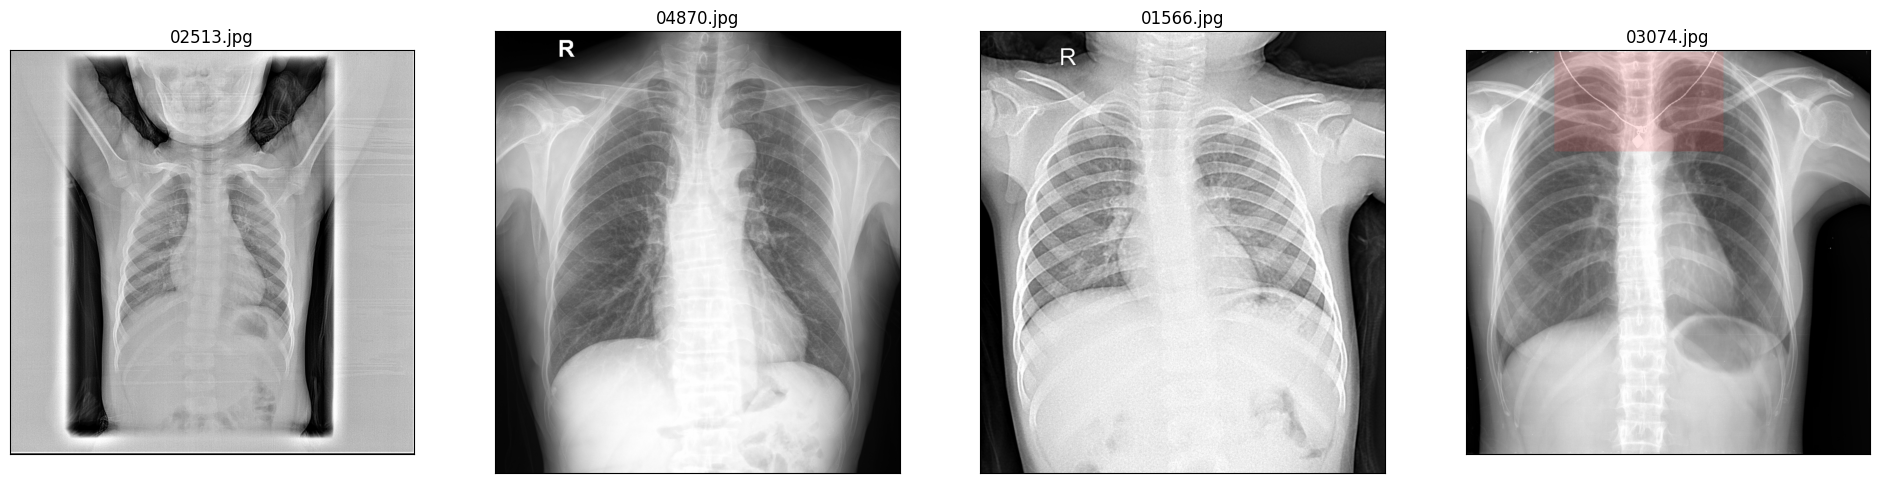

In [9]:
labels_tr = pd.read_csv('/kaggle/input/foreign-objects-in-chest-xrays/object-CXR/train.csv', na_filter=False)
labels_dev = pd.read_csv('/kaggle/input/foreign-objects-in-chest-xrays/object-CXR/dev.csv', na_filter=False)

print(f'{len(os.listdir("/kaggle/input/foreign-objects-in-chest-xrays/object-CXR/train"))} pictures in {data_dir}/train/')
print(f'{len(os.listdir("/kaggle/input/foreign-objects-in-chest-xrays/object-CXR/dev"))} pictures in {data_dir}/dev/')

fig, axs = plt.subplots(
    nrows=1, ncols=4, subplot_kw=dict(xticks=[], yticks=[]), figsize=(24, 6)
)

for row, ax in zip(
    labels_tr.iloc[example_idxes].itertuples(index=False), axs
):
    im = Image.open(data_dir + "/train/" + row.image_name).convert("RGB")
    if row.annotation:
        draw_annotation(im, row.annotation)
    
    ax.imshow(im)
    ax.set_title(f"{row.image_name}")

In [10]:
labels_tr = labels_tr.loc[labels_tr['annotation'].astype(bool)].reset_index(drop=True)
img_class_dict_tr = dict(zip(labels_tr.image_name, labels_tr.annotation))
img_class_dict_dev = dict(zip(labels_dev.image_name, labels_dev.annotation))

In [11]:
class ForeignObjectDataset(object):
    
    def __init__(self, datafolder, datatype='train', transform = True, labels_dict={}):
        self.datafolder = datafolder
        self.datatype = datatype
        self.labels_dict = labels_dict
        self.image_files_list = [s for s in sorted(os.listdir(datafolder)) if s in labels_dict.keys()]
        self.transform = transform
        self.annotations = [labels_dict[i] for i in self.image_files_list]
            
    def __getitem__(self, idx):
        img_name = self.image_files_list[idx]
        img_path = os.path.join(self.datafolder, img_name)
        img = Image.open(img_path).convert("RGB")
        width, height = img.size[0],img.size[1]  
        
        if self.datatype == 'train':
            annotation = self.labels_dict[img_name]
            
            boxes = []
            
            if type(annotation) == str:
                annotation_list = annotation.split(';')
                for anno in annotation_list:
                    x = []
                    y = []
                
                    anno = anno[2:]
                    anno = anno.split(' ')
                    for i in range(len(anno)):
                        if i % 2 == 0:
                            x.append(float(anno[i]))
                        else:
                            y.append(float(anno[i]))
                        
                    xmin = min(x)/width * 600
                    xmax = max(x)/width * 600
                    ymin = min(y)/height * 600
                    ymax = max(y)/height * 600
                    boxes.append([xmin, ymin, xmax, ymax])


            boxes = torch.as_tensor(boxes, dtype=torch.float32)
  
            labels = torch.ones((len(boxes),), dtype=torch.int64)

            image_id = torch.tensor([idx])
            area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])

            iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)

            target = {}
            target["boxes"] = boxes
            target["labels"] = labels
            target["image_id"] = image_id
            target["area"] = area
            target["iscrowd"] = iscrowd
            
            if self.transform is not None:
                img = self.transform(img)
                
            return img, target
        
        if self.datatype == 'dev':
            
            if self.labels_dict[img_name] == '':
                label = 0
            else:
                label = 1
            
            if self.transform is not None:
                img = self.transform(img)

            return img, label, width, height

        

    def __len__(self):
        return len(self.image_files_list)

In [12]:
data_transforms = transforms.Compose([
    transforms.Resize((600,600)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

dataset_train = ForeignObjectDataset(datafolder= data_dir + '/train/', datatype='train', transform=data_transforms, labels_dict=img_class_dict_tr)
dataset_dev = ForeignObjectDataset(datafolder= data_dir + '/dev/', datatype='dev', transform=data_transforms, labels_dict=img_class_dict_dev)

In [13]:
data_loader = DataLoader(
    dataset_train, batch_size=8, shuffle=True, num_workers=4,
    collate_fn=collate_fn
)

data_loader_val = DataLoader(
    dataset_dev, batch_size=1, shuffle=False, num_workers=4,
    collate_fn=collate_fn
)


In [14]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def _get_detection_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

In [ ]:
model_ft = _get_detection_model(num_classes)
model_ft.to(device)

params = [p for p in model_ft.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005,
                            momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                               step_size=5,
                                               gamma=0.1)

num_epochs = 5

auc_max = 0

for epoch in range(num_epochs):
    
    train_one_epoch(model_ft, optimizer, data_loader, device, epoch, print_freq=50)
    
    lr_scheduler.step()
    
    model_ft.eval()
    val_pred = []
    val_label = []
    for batch_i, (image, label,  width, height) in enumerate(data_loader_val):
        image = list(img.to(device) for img in image)
        
        val_label.append(label[-1])

        outputs = model_ft(image)
        if len(outputs[-1]['boxes']) == 0:
            val_pred.append(0)
        else:
            val_pred.append(torch.max(outputs[-1]['scores']).tolist())
    
    val_pred_label = []
    for i in range(len(val_pred)):
        if val_pred[i] >= 0.5:
            val_pred_label.append(1)
        else:
            val_pred_label.append(0)
            
    number = 0
    
    for i in range(len(val_pred_label)):
        if val_pred_label[i] == val_label[i]:
            number += 1
    acc = number / len(val_pred_label)
    
    auc = roc_auc_score(val_label,val_pred)
    print('Epoch: ', epoch, '| val acc: %.4f' % acc, '| val auc: %.4f' % auc)
    
    if auc > auc_max:
        auc_max = auc
        print('Best Epoch: ', epoch, '| val acc: %.4f' % acc, '| Best val auc: %.4f' % auc_max)
        torch.save(model_ft.state_dict(), "model.pt")

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:00<00:00, 221MB/s] 


Epoch: [0]  [  0/500]  eta: 0:35:49  lr: 0.000015  loss: 2.8675 (2.8675)  loss_classifier: 2.3585 (2.3585)  loss_box_reg: 0.0217 (0.0217)  loss_objectness: 0.4749 (0.4749)  loss_rpn_box_reg: 0.0125 (0.0125)  time: 4.2984
Epoch: [0]  [ 50/500]  eta: 0:06:42  lr: 0.000516  loss: 0.3231 (0.5688)  loss_classifier: 0.1161 (0.2949)  loss_box_reg: 0.0806 (0.0706)  loss_objectness: 0.0985 (0.1859)  loss_rpn_box_reg: 0.0126 (0.0174)  time: 0.8249


In [ ]:
model = _get_detection_model(num_classes)
model.to(device)
model.load_state_dict(torch.load("model.pt"))

model.eval()

preds = []
labels = []
locs = []

for image, label, width, height in tqdm(data_loader_val):
    
    image = list(img.to(device) for img in image)
    labels.append(label[-1])
    
    outputs = model(image)
    
    center_points = []
    center_points_preds = []
    
    if len(outputs[-1]['boxes']) == 0:
        preds.append(0)
        center_points.append([])
        center_points_preds.append('')
        locs.append('')
    else:
        preds.append(torch.max(outputs[-1]['scores']).tolist())
        
        new_output_index = torch.where((outputs[-1]['scores']>0.1))
        new_boxes = outputs[-1]['boxes'][new_output_index]
        new_scores = outputs[-1]['scores'][new_output_index]
        
        for i in range(len(new_boxes)):
            new_box = new_boxes[i].tolist()
            center_x = (new_box[0] + new_box[2])/2
            center_y = (new_box[1] + new_box[3])/2
            center_points.append([center_x/600 * width[-1],center_y/600 * height[-1]])
        center_points_preds += new_scores.tolist()
        
        line = ''
        for i in range(len(new_boxes)):
            if i == len(new_boxes)-1:
                line += str(center_points_preds[i]) + ' ' + str(center_points[i][0]) + ' ' + str(center_points[i][1])
            else:
                line += str(center_points_preds[i]) + ' ' + str(center_points[i][0]) + ' ' + str(center_points[i][1]) +';'
        locs.append(line)

cls_res = pd.DataFrame({'image_name': dataset_dev.image_files_list, 'prediction': preds})
cls_res.to_csv('classification.csv', columns=['image_name', 'prediction'], sep=',', index=None)
print('classification.csv generated.')

loc_res = pd.DataFrame({'image_name': dataset_dev.image_files_list, 'prediction': locs})
loc_res.to_csv('localization.csv', columns=['image_name', 'prediction'], sep=',', index=None)
print('localization.csv generated.')

In [ ]:
pred = cls_res.prediction.values
gt = labels_dev.annotation.astype(bool).astype(float).values

In [ ]:
from sklearn.metrics import roc_curve, auc

acc = ((pred >= 0.5) == gt).mean()
fpr, tpr, _ = roc_curve(gt, pred)
roc_auc = auc(fpr, tpr)

print(f"Accuracy: {acc}")
print(f"AUC: {roc_auc}")

In [ ]:
fig, ax = plt.subplots(
    subplot_kw=dict(xlim=[0, 1], ylim=[0, 1], aspect='equal'),
    figsize=(6, 6)
)
ax.plot(fpr, tpr, label=f'ACC: {acc:.03}\nAUC: {roc_auc:.03}')
_ = ax.legend(loc="lower right")
_ = ax.set_title('ROC curve')
ax.grid(linestyle='dashed')

In [ ]:
img_dir_train = "/kaggle/input/foreign-objects-in-chest-xrays/object-CXR/train"
img_dir_val = "/kaggle/input/foreign-objects-in-chest-xrays/object-CXR/dev"

def convert_to_yolo_format(img_dir, labels_dict, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    for img_name, annotation in labels_dict.items():
        if annotation:
            img_path = os.path.join(img_dir, img_name)
            if not os.path.exists(img_path):
                print(f"Image not found: {img_path}")
                continue
            img = Image.open(img_path)
            width, height = img.size

            yolo_annotations = []
            for anno in annotation.split(';'):
                x, y = [], []
                coords = anno[2:].split()
                for i, val in enumerate(coords):
                    if i % 2 == 0:
                        x.append(float(val) / width)
                    else:
                        y.append(float(val) / height)
                x_center = (min(x) + max(x)) / 2
                y_center = (min(y) + max(y)) / 2
                w = max(x) - min(x)
                h = max(y) - min(y)
                yolo_annotations.append(f"0 {x_center} {y_center} {w} {h}")

            txt_path = os.path.join(output_dir, os.path.splitext(img_name)[0] + '.txt')
            with open(txt_path, 'w') as f:
                f.write('\n'.join(yolo_annotations))

convert_to_yolo_format(img_dir_train, img_class_dict_tr, '/kaggle/working/data/train/labels')
convert_to_yolo_format(img_dir_val, img_class_dict_dev, '/kaggle/working/data/val/labels')

In [ ]:
data_config = {
    'train': '/kaggle/input/foreign-objects-in-chest-xrays/object-CXR/train',
    'val': '/kaggle/input/foreign-objects-in-chest-xrays/object-CXR/dev',
    'nc': 1,                                    
    'names': ['foreign_object']                
}

# Save the configuration to data.yaml
yaml_path = '/kaggle/working/data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print(f"'data.yaml' created at: {yaml_path}")

In [ ]:
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

model = YOLO('yolov5n.pt')

model.train(
    data='/kaggle/working/data.yaml', 
    epochs=10,                         
    imgsz=480,                        
    batch=16,                         
    workers=0,                        
    name='foreign_object_detection'   
)

In [ ]:
results = model.val()
print(results)

In [ ]:
model = YOLO('runs/train/foreign_object_detection/weights/best.pt')

test_dir = '/kaggle/input/foreign-objects-in-chest-xrays/object-CXR/dev'

test_images = sorted([os.path.join(test_dir, img) for img in os.listdir(test_dir) if img.endswith('.jpg')])

test_images = test_images[:5]  

results = model.predict(source=test_images, conf=0.5)

for i, result in enumerate(results):

    original_image = Image.open(test_images[i])
    

    plt.figure(figsize=(8, 8))
    plt.imshow(result.plot())
    plt.axis('off') 
    plt.title(f"Prediction for {os.path.basename(test_images[i])}")
    plt.show()